# Модуль 6. Деревья и ансамбли

Ноутбук к [модулю 6](https://drobyshevdev.github.io/lemma/modules/06-trees-and-ensembles/).

Дерево, бэггинг и градиентный бустинг пишутся здесь с нуля — около сотни строк на всё. Библиотечная реализация скрывает ровно то, что надо увидеть: что бустинг делает шаг против градиента, а лес выигрывает, ухудшая каждое отдельное дерево.

Считается за десятки секунд на CPU.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Решающее дерево с нуля

Жадное разбиение: на каждом узле перебираем признаки и пороги, берём то, что сильнее всего уменьшает разнобой.

Пороги берём по квантилям, а не все подряд: качество то же, скорость на порядок выше.

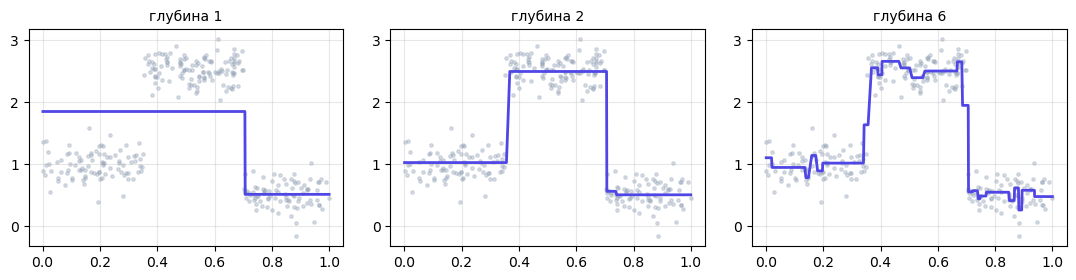

In [2]:
N_THRESHOLDS = 24

def best_split(X, y):
    """Признак и порог с наибольшим уменьшением взвешенной дисперсии."""
    best = (None, None, 0.0)
    parent = y.var() * len(y)
    for j in range(X.shape[1]):
        qs = np.quantile(X[:, j], np.linspace(0.05, 0.95, N_THRESHOLDS))
        for t in np.unique(qs):
            left = X[:, j] <= t
            nl = int(left.sum())
            if nl < 5 or len(y) - nl < 5:
                continue
            gain = parent - (y[left].var() * nl + y[~left].var() * (len(y) - nl))
            if gain > best[2]:
                best = (j, float(t), float(gain))
    return best

def build_tree(X, y, depth, features=None, rng=None):
    """features=k -- смотреть только k случайных признаков на узле (это уже лес)."""
    if depth == 0 or len(y) < 10 or y.var() < 1e-12:
        return {"leaf": float(y.mean())}
    cols = np.arange(X.shape[1])
    if features is not None and features < len(cols):
        cols = rng.choice(cols, features, replace=False)
    j_rel, t, gain = best_split(X[:, cols], y)
    if j_rel is None:
        return {"leaf": float(y.mean())}
    j = int(cols[j_rel])
    mask = X[:, j] <= t
    return {"feature": j, "threshold": t, "gain": gain,
            "left": build_tree(X[mask], y[mask], depth - 1, features, rng),
            "right": build_tree(X[~mask], y[~mask], depth - 1, features, rng)}

def predict_tree(tree, X):
    out = np.empty(len(X))
    for i, row in enumerate(X):
        node = tree
        while "leaf" not in node:
            node = node["left"] if row[node["feature"]] <= node["threshold"] else node["right"]
        out[i] = node["leaf"]
    return out

# Одномерная задача, чтобы увидеть ступеньки.
rng = np.random.default_rng(3)
x1 = np.sort(rng.random(300))[:, None]
y1 = np.where(x1[:, 0] < 0.35, 1.0, np.where(x1[:, 0] < 0.7, 2.5, 0.5)) + rng.normal(0, 0.2, 300)

fig, axes = plt.subplots(1, 3, figsize=(11, 2.9))
for ax, depth in zip(axes, [1, 2, 6]):
    tree = build_tree(x1, y1, depth)
    ax.scatter(x1[:, 0], y1, s=6, alpha=0.35, color="#94a3b8")
    ax.plot(x1[:, 0], predict_tree(tree, x1), color="#4f46e5", lw=2)
    ax.set_title(f"глубина {depth}", fontsize=10)
plt.tight_layout(); plt.show()

Дерево кусочно-постоянно: оно не умеет наклон, только ступеньки. При глубине 2 оно нашло обе настоящие границы (0.35 и 0.7). При глубине 6 начало ловить шум.

**Сломайте:** сделайте истинную зависимость линейной, `y = 3x`. Сколько глубины нужно дереву, чтобы прилично приблизить прямую? Сравните с одним весом линейной модели.

## 2. Глубина и переобучение

Те же две кривые, что в модуле 2, только вместо степени многочлена — глубина.

In [3]:
def make_tabular(n=1200, seed=0):
    """Табличная задача: пороги и взаимодействие -- то, что бывает в реальных данных."""
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, size=(n, 5))
    y = (2.0 * (X[:, 0] > 0.5)                    # порог
         - 1.5 * (X[:, 1] < -0.3)                 # ещё порог
         + 1.2 * (X[:, 0] > 0) * (X[:, 2] > 0)    # взаимодействие
         + 0.4 * X[:, 3]                          # линейная часть
         + rng.normal(0, 0.4, n))                 # шум
    return X, y

X, y = make_tabular(1200, seed=0)
Xv, yv = make_tabular(3000, seed=99)

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

depths = range(1, 11)
tr, va = [], []
for d in depths:
    t = build_tree(X, y, d)
    tr.append(rmse(predict_tree(t, X), y))
    va.append(rmse(predict_tree(t, Xv), yv))

print("глубина   на обучении   на новых")
for d, a, b in zip(depths, tr, va):
    mark = "  <- лучшая" if b == min(va) else ""
    print(f"{d:>7}   {a:>11.3f}   {b:>8.3f}{mark}")

глубина   на обучении   на новых
      1         1.065      1.042
      2         0.760      0.771
      3         0.625      0.653
      4         0.554      0.605
      5         0.461      0.525  <- лучшая
      6         0.418      0.526
      7         0.384      0.543
      8         0.357      0.558
      9         0.339      0.571
     10         0.330      0.575


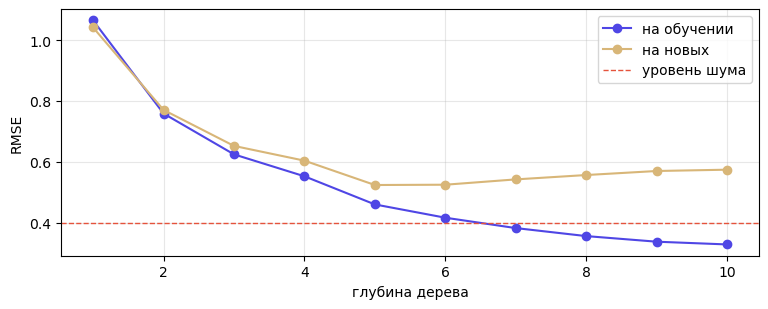

In [4]:
fig, ax = plt.subplots()
ax.plot(list(depths), tr, marker="o", label="на обучении", color="#4f46e5")
ax.plot(list(depths), va, marker="o", label="на новых", color="#d8b678")
ax.axhline(0.4, color="#e5533c", ls="--", lw=1, label="уровень шума")
ax.set_xlabel("глубина дерева"); ax.set_ylabel("RMSE"); ax.legend()
plt.show()

## 3. Бэггинг: дисперсия падает как 1/M

Из модуля 2: дисперсия среднего $M$ независимых величин в $M$ раз меньше. Проверим на моделях вместо наблюдений.

In [5]:
def fit_bag(X, y, n_trees, depth=8, features=None, seed=0):
    rng = np.random.default_rng(seed)
    trees = []
    for _ in range(n_trees):
        idx = rng.integers(0, len(y), len(y))          # бутстрэп из модуля 1
        trees.append(build_tree(X[idx], y[idx], depth, features, rng))
    return trees

def predict_bag(trees, X):
    return np.mean([predict_tree(t, X) for t in trees], axis=0)

Xs, ys = make_tabular(600, seed=1)
sizes = [1, 2, 5, 10, 25]

print(f"{'деревьев':>9} {'RMSE бэггинг':>14} {'RMSE лес':>11}")
bag_err, forest_err = [], []
for m in sizes:
    b = rmse(predict_bag(fit_bag(Xs, ys, m, seed=7), Xv), yv)
    f = rmse(predict_bag(fit_bag(Xs, ys, m, features=2, seed=7), Xv), yv)
    bag_err.append(b); forest_err.append(f)
    print(f"{m:>9} {b:>14.3f} {f:>11.3f}")

 деревьев   RMSE бэггинг    RMSE лес


        1          0.639       0.826


        2          0.571       0.847


        5          0.538       0.624


       10          0.527       0.573


       25          0.513       0.545


**Лес проиграл бэггингу на всех размерах.** 0.545 против 0.513 при двадцати пяти деревьях.

Это не ошибка в коде и не опровержение случайного леса. Это его условие применимости, которое обычно не проговаривают.

Лес выигрывает за счёт раскорреляции: деревья смотрят на разные признаки, их ошибки расходятся, усреднение работает лучше. Плата — каждое дерево видит меньше данных. Выигрыш перекрывает плату, когда признаков много и сигнал по ним размазан.

Здесь признаков пять, и почти весь сигнал сидит в трёх из них. Дерево, которому на узле дали два случайных признака из пяти, регулярно не видит ни одного информативного. Плата есть, выигрыша нет.

Ровно та же логика, что с моментом в модуле 4: приём лечит конкретную болезнь, и на здоровом организме он вредит.

**Сломайте:** сгенерируйте данные с 40 признаками, где сигнал размазан по многим. Найдите, при каком числе признаков лес начинает обыгрывать бэггинг.


## 4. Градиентный бустинг с нуля

Пять строк идеи: константа, остатки, дерево на остатки, добавить с маленьким коэффициентом, повторить.

In [6]:
def fit_boost(X, y, n_trees=80, lr=0.1, depth=3):
    base = float(y.mean())
    pred = np.full(len(y), base)
    trees = []
    for _ in range(n_trees):
        residual = y - pred          # для квадратичной потери это антиградиент
        tree = build_tree(X, residual, depth)
        pred += lr * predict_tree(tree, X)
        trees.append(tree)
    return base, trees, lr

def predict_boost(model, X, n_trees=None):
    base, trees, lr = model
    out = np.full(len(X), base)
    for t in trees[:n_trees]:
        out += lr * predict_tree(t, X)
    return out

model = fit_boost(X, y, n_trees=80, lr=0.1, depth=3)

counts = [1, 2, 5, 10, 20, 40, 80]
print(f"{'деревьев':>9} {'на обучении':>13} {'на новых':>10}")
for m in counts:
    print(f"{m:>9} {rmse(predict_boost(model, X, m), y):>13.3f} "
          f"{rmse(predict_boost(model, Xv, m), yv):>10.3f}")

 деревьев   на обучении   на новых
        1         1.411      1.387
        2         1.299      1.278
        5         1.037      1.027
       10         0.777      0.779
       20         0.548      0.559
       40         0.443      0.478


       80         0.407      0.467


## 5. Скорость обучения против числа деревьев

Из модуля 4: длина шага и число шагов связаны обратно. Здесь ровно то же.

    lr   лучший RMSE   на каком дереве


  0.02         0.531               120


   0.1         0.459               119


   0.5         0.474                17


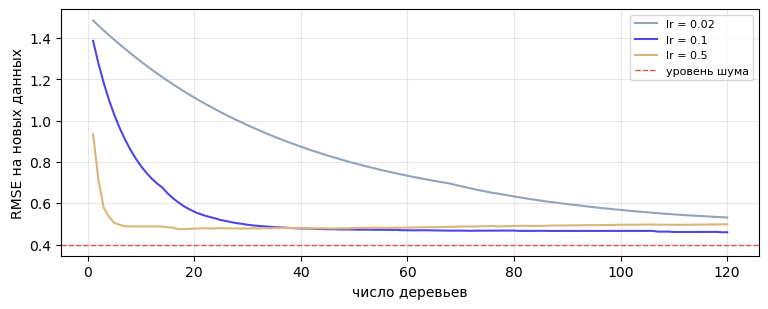

In [7]:
fig, ax = plt.subplots()
print(f"{'lr':>6} {'лучший RMSE':>13} {'на каком дереве':>17}")
for lr, colour in [(0.02, "#94a3b8"), (0.1, "#4f46e5"), (0.5, "#d8b678")]:
    m = fit_boost(X, y, n_trees=120, lr=lr, depth=3)
    curve = [rmse(predict_boost(m, Xv, k), yv) for k in range(1, 121)]
    ax.plot(range(1, 121), curve, color=colour, label=f"lr = {lr}")
    print(f"{lr:>6} {min(curve):>13.3f} {int(np.argmin(curve)) + 1:>17}")
ax.axhline(0.4, color="#e5533c", ls="--", lw=1, label="уровень шума")
ax.set_xlabel("число деревьев"); ax.set_ylabel("RMSE на новых данных")
ax.legend(fontsize=8)
plt.show()

Маленький шаг доходит туда же, но позже. Большой доходит быстро и начинает портиться — это переобучение бустинга, и лечится оно ранней остановкой по валидации.

Правило из текста: уменьшили `lr` вдвое — увеличивайте число деревьев вдвое.

## 6. Бустинг против линейной модели

Главное сравнение модуля. Данные табличные: пороги, взаимодействие и немного линейности.

In [8]:
def fit_linear(X, y):
    Xb = np.hstack([X, np.ones((len(X), 1))])
    return np.linalg.lstsq(Xb, y, rcond=None)[0]

def predict_linear(w, X):
    return np.hstack([X, np.ones((len(X), 1))]) @ w

# Пять разбиений, а не одно: из модуля 1 известно, чего стоит одно число.
lin_scores, boost_scores, tree_scores = [], [], []
for seed in range(5):
    Xt, yt = make_tabular(1200, seed=seed)
    lin_scores.append(rmse(predict_linear(fit_linear(Xt, yt), Xv), yv))
    tree_scores.append(rmse(predict_tree(build_tree(Xt, yt, 5), Xv), yv))
    boost_scores.append(rmse(predict_boost(fit_boost(Xt, yt, 80, 0.1, 3), Xv), yv))

def bootstrap_ci(values, statistic=np.mean, n_resamples=10_000, seed=0):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    draws = rng.choice(values, size=(n_resamples, len(values)), replace=True)
    return np.percentile([statistic(r) for r in draws], [2.5, 97.5])

print(f"{'модель':<22} {'RMSE (среднее по 5)':>20} {'95% интервал':>22}")
for name, s in [("линейная", lin_scores), ("одно дерево, глуб. 5", tree_scores),
                ("бустинг, 80 деревьев", boost_scores)]:
    lo, hi = bootstrap_ci(s)
    print(f"{name:<22} {np.mean(s):>20.3f} {f'[{lo:.3f}, {hi:.3f}]':>22}")
print(f"\nуровень шума в данных: 0.400 -- ниже него не опустится ничто")

модель                  RMSE (среднее по 5)           95% интервал
линейная                              0.954         [0.953, 0.955]
одно дерево, глуб. 5                  0.531         [0.521, 0.541]


бустинг, 80 деревьев                  0.460         [0.449, 0.470]

уровень шума в данных: 0.400 -- ниже него не опустится ничто


Бустинг выигрывает, и интервалы не перекрываются — по правилу модуля 1 разница показана.

Причина в данных, а не в магии: здесь пороги и взаимодействие, то есть ровно то, что дерево строит напрямую, а линейная модель приблизить не может.

**Сломайте:** сделайте `make_tabular` чисто линейной — уберите пороги и взаимодействие, оставьте `y = X @ w + шум`. Кто выиграет теперь? Это и есть ответ на вопрос, когда бустинг не нужен.

## 7. Важности признаков и коллинеарность

Добавим копию информативного признака и посмотрим, что станет с важностями.

In [9]:
def importances(tree, n_features, out=None):
    """Сумма выигрышей по всем разбиениям на каждом признаке."""
    out = np.zeros(n_features) if out is None else out
    if "leaf" in tree:
        return out
    out[tree["feature"]] += tree["gain"]
    importances(tree["left"], n_features, out)
    importances(tree["right"], n_features, out)
    return out

Xd, yd = make_tabular(1200, seed=0)

for label, Xuse in [("без дубликата", Xd),
                    ("с копией признака 0", np.hstack([Xd, Xd[:, [0]] + np.random.default_rng(0).normal(0, 0.01, (len(Xd), 1))]))]:
    t = build_tree(Xuse, yd, 5)
    imp = importances(t, Xuse.shape[1])
    imp = imp / imp.sum()
    print(f"{label}:")
    for j, v in enumerate(imp):
        tag = " (копия признака 0)" if j == 5 else ""
        print(f"    признак {j}: {v:>6.1%}{tag}")
    print()

без дубликата:
    признак 0:  60.3%
    признак 1:  25.9%
    признак 2:   7.3%
    признак 3:   6.4%
    признак 4:   0.0%



с копией признака 0:
    признак 0:   2.6%
    признак 1:  26.0%
    признак 2:   7.1%
    признак 3:   6.7%
    признак 4:   0.2%
    признак 5:  57.5% (копия признака 0)



Истинная зависимость не менялась: признак 0 одинаково информативен в обоих случаях.

Но посмотрите, что стало с числом. **60.3 % превратились в 2.6 %**, а копия забрала 57.5 %. Это даже не деление пополам — дерево на первом же узле выбрало копию, и дальше признак 0 ему был почти не нужен.

Человек, читающий вторую таблицу, сделает вывод, что признак 0 не важен вовсе. Он важен ровно так же, как раньше.

Это то же явление, что разъезжающиеся веса в модуле 3: два способа сказать одно и то же делят между собой заслугу произвольным образом.

**Важность признака — свойство модели, а не данных.** Меряйте вклад в предсказание пермутацией, а выводы про причины не делайте вовсе — это модуль 20.


## Итог

1. Дерево кусочно-постоянно: пороги строит напрямую, наклон не умеет.
2. Глубина ведёт себя как степень многочлена из модуля 2 — те же две кривые, лучшая глубина 5.
3. Случайный лес **проиграл** обычному бэггингу: при пяти признаках плата за раскорреляцию не окупается. Приём лечит конкретную болезнь, а не улучшает всё подряд.
4. Бустинг — градиентный спуск из модуля 4, только шаг делается в пространстве функций.
5. Скорость обучения и число деревьев связаны обратно: при `lr = 0.5` лучший результат достигается на 17-м дереве, при `lr = 0.02` — на 120-м и он хуже.
6. На табличных данных бустинг обыгрывает линейную модель вдвое (0.460 против 0.954), и интервалы не перекрываются.
7. Копия признака отобрала у оригинала 96 % его важности, не изменив ни данных, ни зависимости.

Дальше — [модуль 7](https://drobyshevdev.github.io/lemma/modules/07-honest-comparison/): всё это надо ещё уметь честно сравнивать.
